In [1]:
from obspy.core import read
st = read("https://examples.obspy.org/ev0_6.a01.gse2")
st = st.select(component="Z")
tr = st[0]

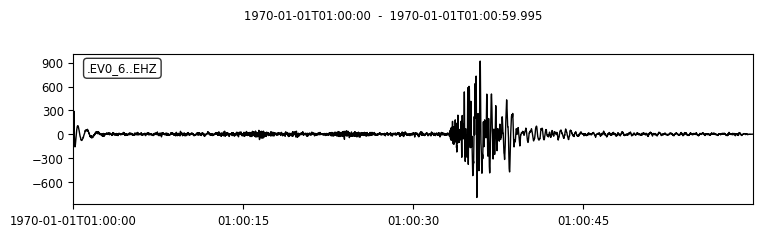

In [2]:
tr.plot();

In [5]:
from obspy.core import Stream, read
st = Stream()
files = ["BW.UH1..SHZ.D.2010.147.cut.slist.gz",
         "BW.UH2..SHZ.D.2010.147.cut.slist.gz",
         "BW.UH3..SHZ.D.2010.147.cut.slist.gz",
         "BW.UH4..SHZ.D.2010.147.cut.slist.gz"]
for filename in files:
    st += read("https://examples.obspy.org/" + filename)

In [6]:
st.filter('bandpass', freqmin=10, freqmax=20)  # optional prefiltering
from obspy.signal.trigger import coincidence_trigger
st2 = st.copy()
trig = coincidence_trigger("recstalta", 3.5, 1, st2, 3, sta=0.5, lta=10)

In [7]:
from pprint import pprint
pprint(trig)


[{'coincidence_sum': 4.0,
  'duration': 4.510000228881836,
  'similarity': {},
  'stations': ['UH3', 'UH2', 'UH1', 'UH4'],
  'time': UTCDateTime(2010, 5, 27, 16, 24, 33, 210000),
  'trace_ids': ['BW.UH3..SHZ', 'BW.UH2..SHZ', 'BW.UH1..SHZ', 'BW.UH4..SHZ']},
 {'coincidence_sum': 3.0,
  'duration': 3.440000057220459,
  'similarity': {},
  'stations': ['UH2', 'UH3', 'UH1'],
  'time': UTCDateTime(2010, 5, 27, 16, 27, 1, 260000),
  'trace_ids': ['BW.UH2..SHZ', 'BW.UH3..SHZ', 'BW.UH1..SHZ']},
 {'coincidence_sum': 4.0,
  'duration': 4.769999742507935,
  'similarity': {},
  'stations': ['UH3', 'UH2', 'UH1', 'UH4'],
  'time': UTCDateTime(2010, 5, 27, 16, 27, 30, 510000),
  'trace_ids': ['BW.UH3..SHZ', 'BW.UH2..SHZ', 'BW.UH1..SHZ', 'BW.UH4..SHZ']}]
